# EDA Datathon 2026 - Exploratory Data Analysis


---
## Thiết lập môi trường và đường dẫn dữ liệu
---

In [ ]:
from pathlib import Path
from scipy.stats import linregress

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "dataset"
files_csv = sorted(DATA_DIR.glob("*.csv"))
print(f"Đã nhận diện {len(files_csv)} file CSV trong {DATA_DIR}:")
for file_path in files_csv:
    print(f"  {file_path.name}")


---
## Import thư viện & Cấu hình style

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import squarify
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

C_1       = "#4F6FA3"
C_2       = "#537FA3"
C_3       = "#4FA3A0"
C_4       = "#56B2A6"
C_5       = "#78C09E"
C_6       = "#94C88C"
C_PALETTE = [C_1, C_2, C_3, C_4, C_5, C_6,
             "#B6D97F", "#D6E87A", "#E3EE7A"]

plt.rcParams.update({
    "figure.dpi":        120,
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "legend.framealpha": 0.8,
})

def fmt_mil(x, _=None):
    if abs(x) >= 1e9:  return f"{x/1e9:.1f} tỷ VND"
    if abs(x) >= 1e6:  return f"{x/1e6:.1f} triệu VND"
    if abs(x) >= 1e3:  return f"{x/1e3:.0f} nghìn VND"
    return f"{x:.0f} VND"

print("Import hoàn tất. Sẵn sàng phân tích!")

Import hoàn tất. Sẵn sàng phân tích!


## Load toàn bộ dữ liệu

In [ ]:
orders      = pd.read_csv(DATA_DIR / "orders.csv",      parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv")
products    = pd.read_csv(DATA_DIR / "products.csv")
customers   = pd.read_csv(DATA_DIR / "customers.csv",   parse_dates=["signup_date"])
geography   = pd.read_csv(DATA_DIR / "geography.csv")
promotions  = pd.read_csv(DATA_DIR / "promotions.csv",  parse_dates=["start_date","end_date"])
returns     = pd.read_csv(DATA_DIR / "returns.csv",     parse_dates=["return_date"])
reviews     = pd.read_csv(DATA_DIR / "reviews.csv",     parse_dates=["review_date"])
payments    = pd.read_csv(DATA_DIR / "payments.csv")
shipments   = pd.read_csv(DATA_DIR / "shipments.csv",   parse_dates=["ship_date","delivery_date"])
sales       = pd.read_csv(DATA_DIR / "sales.csv",       parse_dates=["Date"])
inventory   = pd.read_csv(DATA_DIR / "inventory.csv",   parse_dates=["snapshot_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])

print("=" * 55)
print(f"{'Bảng':<15} {'Rows':>10} {'Cols':>6}")
print("=" * 55)
for name, df in [("orders",orders),("order_items",order_items),("products",products),
                 ("customers",customers),("geography",geography),("promotions",promotions),
                 ("returns",returns),("reviews",reviews),("payments",payments),
                 ("shipments",shipments),("sales",sales),("inventory",inventory),
                 ("web_traffic",web_traffic)]:
    print(f"  {name:<13} {len(df):>10,} {df.shape[1]:>6}")
print("=" * 55)

Bảng                  Rows   Cols
  orders           646,945      8
  order_items      714,669      7
  products           2,412      8
  customers        121,930      7
  geography         39,948      4
  promotions            50     10
  returns           39,939      7
  reviews          113,551      7
  payments         646,945      4
  shipments        566,067      4
  sales              3,833      3
  inventory         60,247     17
  web_traffic        3,652      7


##  Join bảng & Tính chỉ số tài chính

In [ ]:
oi = order_items.merge(
    orders[["order_id","order_date","customer_id","zip",
            "order_status","order_source","device_type","payment_method"]],
    on="order_id", how="left")

oi = oi.merge(
    products[["product_id","product_name","category","segment","size","color","price","cogs"]],
    on="product_id", how="left")

oi = oi.merge(
    customers[["customer_id","gender","age_group","acquisition_channel"]],
    on="customer_id", how="left")

oi = oi.merge(
    geography[["zip","region","city"]].drop_duplicates("zip"),
    on="zip", how="left")

ship_merged = shipments.merge(
    orders[["order_id","order_status"]], on="order_id", how="left")
ship_merged["delivery_days"] = (
    ship_merged["delivery_date"] - ship_merged["ship_date"]).dt.days
ship_merged = ship_merged[ship_merged["delivery_days"].between(0, 60)]

oi["revenue"]       = oi["quantity"] * oi["unit_price"]
oi["gross_revenue"] = oi["quantity"] * oi["price"]
oi["cogs_total"]    = oi["quantity"] * oi["cogs"]
oi["gross_profit"]  = oi["revenue"] - oi["cogs_total"]
oi["gross_margin"]  = oi["gross_profit"] / oi["revenue"].replace(0, np.nan)
oi["has_promo"]     = oi["promo_id"].notna()
oi["year"]          = oi["order_date"].dt.year
oi["month"]         = oi["order_date"].dt.month
oi["yearmonth"]     = oi["order_date"].dt.to_period("M")

oi_valid = oi[oi["order_status"].isin(["delivered","shipped"])].copy()

sales["year"]  = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.month
sales["ym"]    = sales["Date"].dt.to_period("M")
monthly_sales  = sales.groupby("ym").agg(
    Revenue=("Revenue","sum"), COGS=("COGS","sum")).reset_index()
monthly_sales["GrossProfit"] = monthly_sales["Revenue"] - monthly_sales["COGS"]
monthly_sales["GrossMargin"] = monthly_sales["GrossProfit"] / monthly_sales["Revenue"]
monthly_sales["date"]        = monthly_sales["ym"].dt.to_timestamp()

print(f"Master DF (tất cả):    {len(oi):>10,} rows")
print(f"Master DF (hợp lệ):    {len(oi_valid):>10,} rows")
print(f"\nKiểm tra cột master DF:")
print(oi_valid.dtypes)

Master DF (tất cả):       714,669 rows
Master DF (hợp lệ):       585,981 rows

Kiểm tra cột master DF:
order_id                        int64
product_id                      int64
quantity                        int64
unit_price                    float64
discount_amount               float64
promo_id                       object
promo_id_2                     object
order_date             datetime64[ns]
customer_id                     int64
zip                             int64
order_status                   object
order_source                   object
device_type                    object
payment_method                 object
product_name                   object
category                       object
segment                        object
size                           object
color                          object
price                         float64
cogs                          float64
gender                         object
age_group                      object
acquisition_channel    

---
## Hình 1. Executive Summary KPI

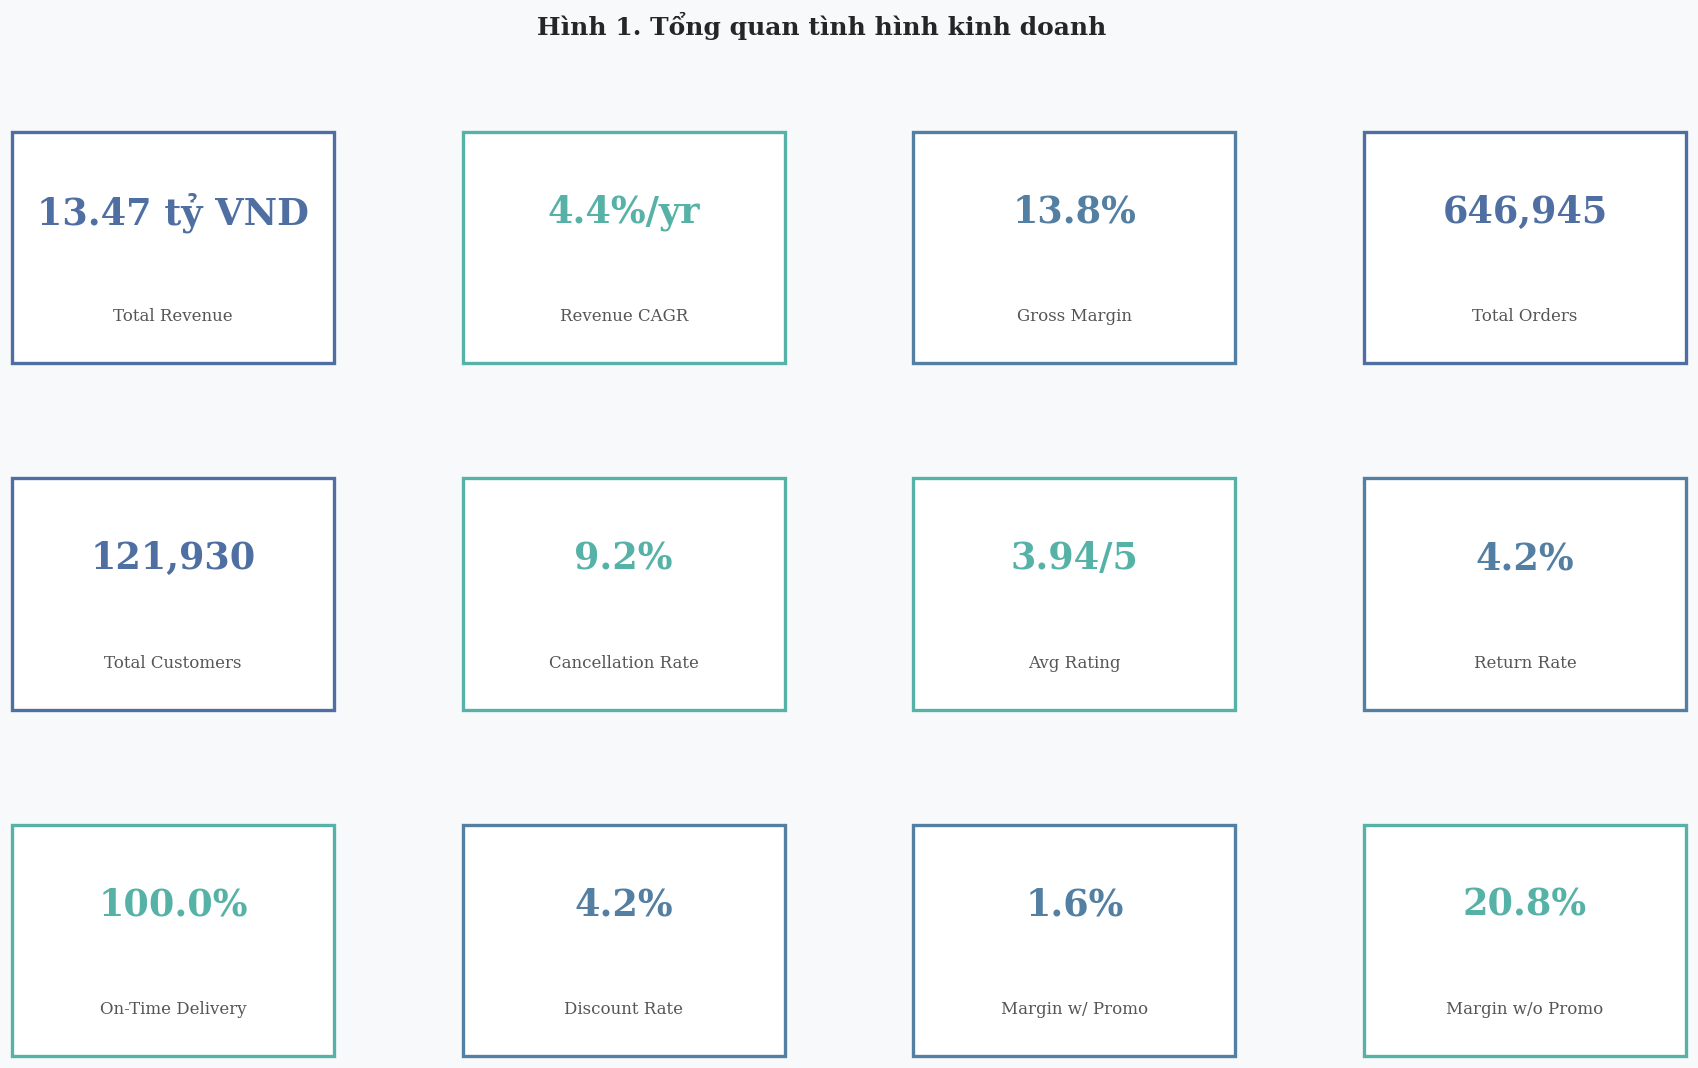

0. Revenue CAGR (2012–2022):      4.4%/yr
1. Gross Margin WITH Promo:    1.6% vs WITHOUT: 20.8%
   → Chênh lệch: 19.2 pp — Promo đang bào mòn margin nghiêm trọng
2. Discount chiếm 4.2% Gross Revenue — cần kiểm soát chặt hơn
3. Cancellation Rate: 9.2% — Trong ngưỡng kiểm soát
4. Avg Rating: 3.94/5 — Chất lượng sản phẩm tốt
5. On-Time Delivery: 100.0% — Đạt SLA


In [ ]:
total_rev      = oi_valid["revenue"].sum()
total_gp       = oi_valid["gross_profit"].sum()
total_margin   = total_gp / total_rev * 100
total_orders   = orders["order_id"].nunique()
cancel_rate    = (orders["order_status"]=="cancelled").mean() * 100
total_cust     = customers["customer_id"].nunique()
avg_rating     = reviews["rating"].mean()
return_rate    = returns["return_quantity"].sum() / oi_valid["quantity"].sum() * 100
ontime_pct     = (ship_merged["delivery_days"] <= 7).mean() * 100
discount_pct   = oi_valid["discount_amount"].sum() / oi_valid["gross_revenue"].sum() * 100
promo_margin   = oi_valid[oi_valid["has_promo"]]["gross_margin"].mean() * 100
nopromo_margin = oi_valid[~oi_valid["has_promo"]]["gross_margin"].mean() * 100

oi_valid["order_year"] = pd.to_datetime(oi_valid["order_date"]).dt.year
rev_by_year   = oi_valid.groupby("order_year")["revenue"].sum()
first_yr, last_yr = rev_by_year.index.min(), rev_by_year.index.max()
n_years       = last_yr - first_yr
cagr          = ((rev_by_year[last_yr] / rev_by_year[first_yr]) ** (1 / n_years) - 1) * 100

kpis = [
    ("Total Revenue", f"{total_rev/1e9:.2f} tỷ VND", C_1),
    ("Revenue CAGR",        f"{cagr:.1f}%/yr",                   C_4 if cagr > 0 else C_3),  # thay Gross Profit
    ("Gross Margin",        f"{total_margin:.1f}%",       C_4 if total_margin>35 else C_2),
    ("Total Orders",        f"{total_orders:,}",          C_1),
    ("Total Customers",     f"{total_cust:,}",            C_1),
    ("Cancellation Rate",   f"{cancel_rate:.1f}%",        C_3 if cancel_rate>10 else C_4),
    ("Avg Rating",          f"{avg_rating:.2f}/5",        C_4 if avg_rating>=3.5 else C_3),
    ("Return Rate",         f"{return_rate:.1f}%",        C_3 if return_rate>15 else C_2),
    ("On-Time Delivery",    f"{ontime_pct:.1f}%",         C_4 if ontime_pct>80 else C_3),
    ("Discount Rate",       f"{discount_pct:.1f}%",       C_3 if discount_pct>20 else C_2),
    ("Margin w/ Promo",     f"{promo_margin:.1f}%",       C_2),
    ("Margin w/o Promo",    f"{nopromo_margin:.1f}%",     C_4),
]

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#F8F9FA")
gs = GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)
positions = [(r, c) for r in range(3) for c in range(4)]

for (label, value, color), (row, col) in zip(kpis, positions):
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor("white")
    ax.text(0.5, 0.65, value, transform=ax.transAxes,
            ha="center", va="center", fontsize=22, fontweight="bold", color=color)
    ax.text(0.5, 0.2, label, transform=ax.transAxes,
            ha="center", va="center", fontsize=10, color="#555555")
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.patch.set_linewidth(2)
    ax.patch.set_edgecolor(color)

fig.suptitle("Hình 1. Tổng quan tình hình kinh doanh",
             fontsize=15, fontweight="bold", y=0.98)
plt.show()

print(f"0. Revenue CAGR ({first_yr}–{last_yr}):      {cagr:.1f}%/yr")
print(f"1. Gross Margin WITH Promo:    {promo_margin:.1f}% vs WITHOUT: {nopromo_margin:.1f}%")
print(f"   → Chênh lệch: {nopromo_margin-promo_margin:.1f} pp — Promo đang bào mòn margin nghiêm trọng")
print(f"2. Discount chiếm {discount_pct:.1f}% Gross Revenue — cần kiểm soát chặt hơn")
print(f"3. Cancellation Rate: {cancel_rate:.1f}% — {'Cần cải thiện' if cancel_rate>10 else 'Trong ngưỡng kiểm soát'}")
print(f"4. Avg Rating: {avg_rating:.2f}/5 — Chất lượng sản phẩm {'tốt' if avg_rating>=3.5 else 'cần cải thiện'}")
print(f"5. On-Time Delivery: {ontime_pct:.1f}% — {'Đạt SLA' if ontime_pct>80 else 'Chưa đạt SLA 80%'}")

---
## Hình 2. Revenue & Gross Profit Trend

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

rev_mil = monthly_sales["Revenue"] / 1e6

ax1.fill_between(monthly_sales["date"], rev_mil, alpha=0.2, color=C_1)
ax1.plot(monthly_sales["date"], rev_mil,
         color=C_1, lw=2, label="Revenue (triệu VND)")

ax2.plot(monthly_sales["date"], monthly_sales["GrossMargin"] * 100,
         color=C_3, lw=1.5, linestyle=":", label="Gross Margin %")

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

ax1.set_xlabel("Thời gian")
ax1.set_ylabel("Revenue (triệu VND)", color=C_1)
ax2.set_ylabel("Gross Margin %", color=C_3)

ax2.spines["right"].set_visible(True)
ax2.spines["top"].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(1.08, 1),
    borderaxespad=0,
    frameon=True
)

ax1.set_title("Hình 2. Xu hướng Doanh thu & Biên lợi nhuận gộp (2012–2022)")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

---
## Hình 3. Seasonality Heatmap

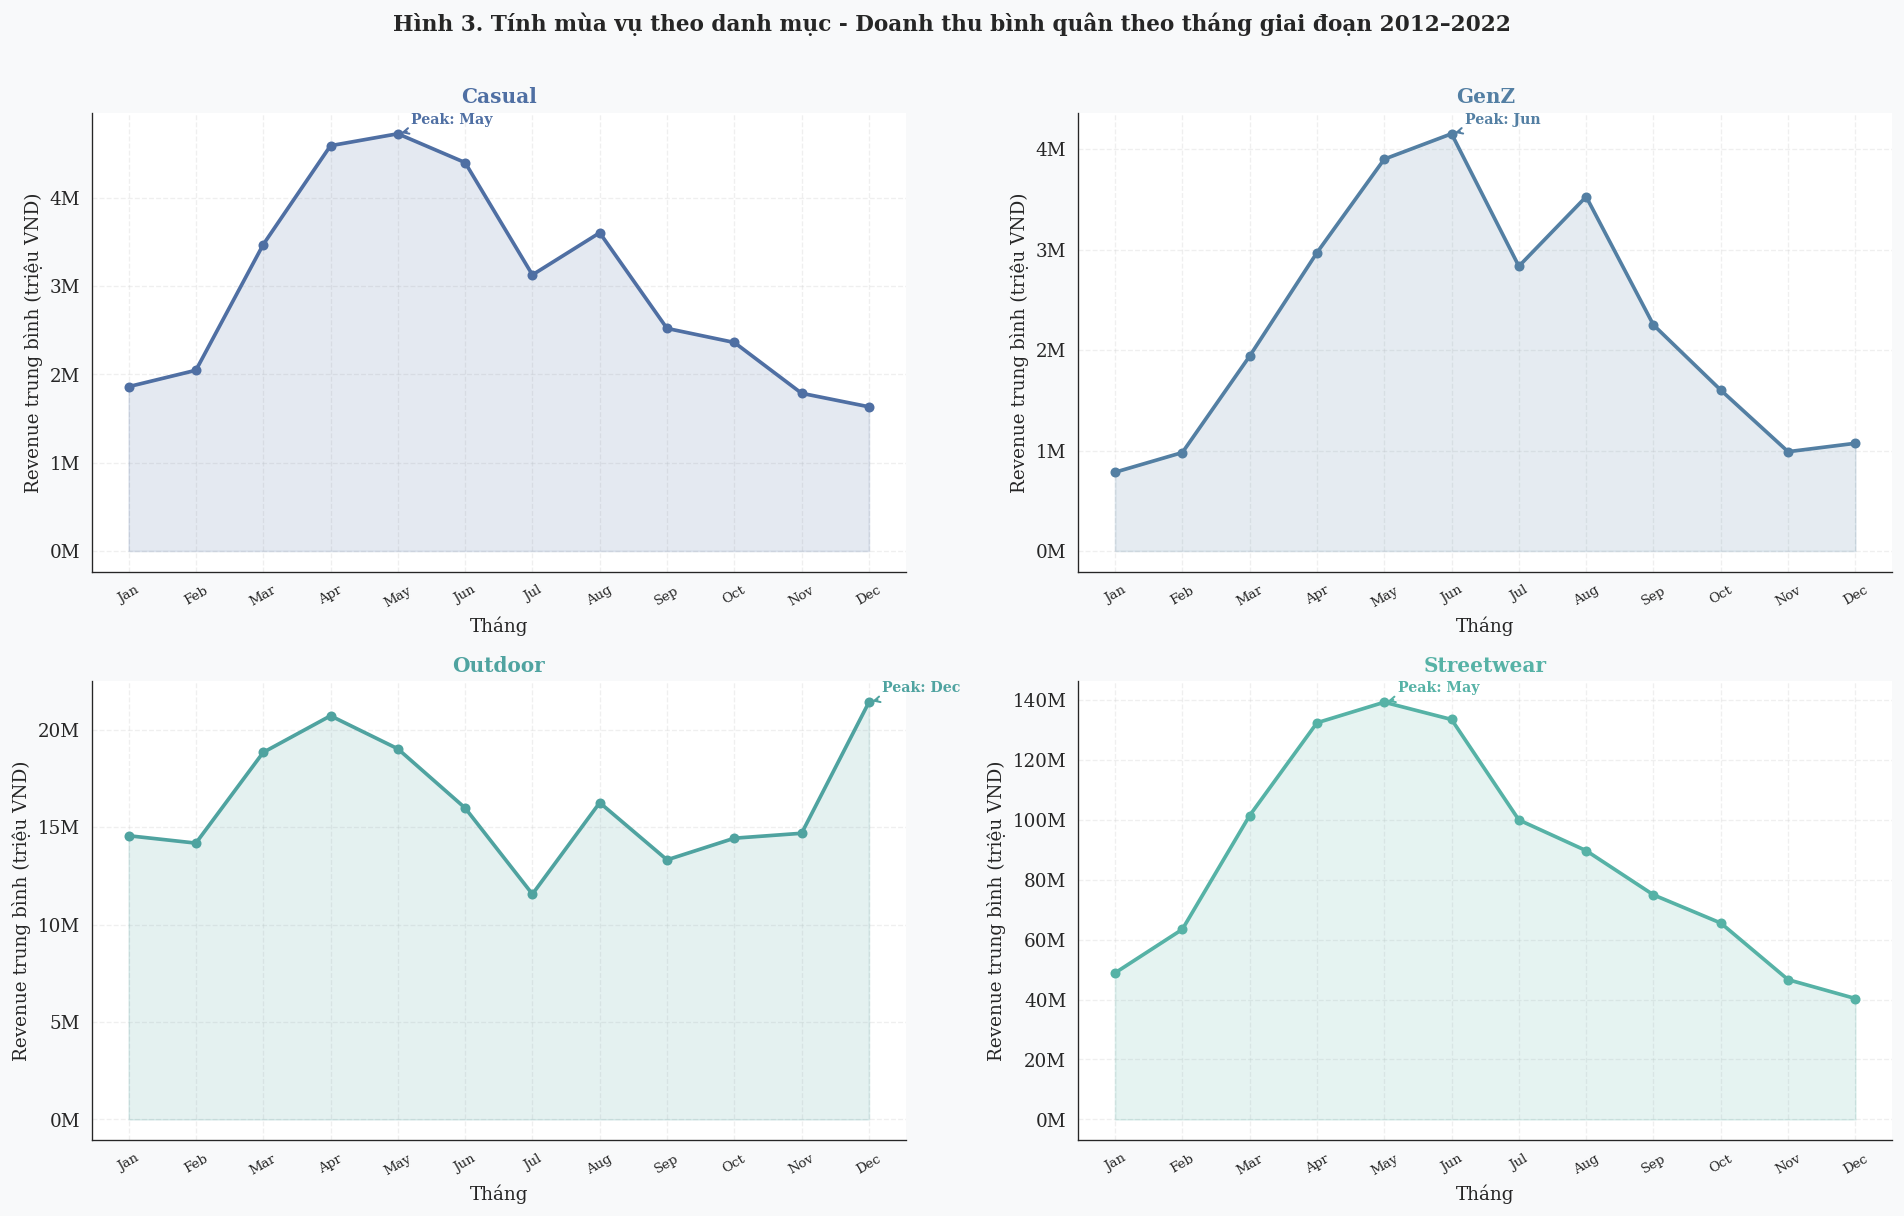

In [ ]:
cat_monthly = (
    oi_valid.groupby(["category", "year", "month"])["revenue"]
    .sum()
    .groupby(["category", "month"])
    .mean()
    .reset_index()
)

months_label = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
categories   = sorted(cat_monthly["category"].unique())
palette      = C_PALETTE[:len(categories)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#F8F9FA")
axes = axes.flatten()

for i, (cat, color) in enumerate(zip(categories, palette)):
    ax  = axes[i]
    sub = cat_monthly[cat_monthly["category"] == cat].sort_values("month")

    ax.fill_between(sub["month"], sub["revenue"] / 1e6, alpha=0.15, color=color)
    ax.plot(sub["month"], sub["revenue"] / 1e6,
            marker="o", markersize=5, lw=2.2, color=color)

    peak = sub.loc[sub["revenue"].idxmax()]
    ax.annotate(f"Peak: {months_label[int(peak['month'])-1]}",
                xy=(peak["month"], peak["revenue"] / 1e6),
                xytext=(8, 6), textcoords="offset points",
                fontsize=8.5, color=color, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=color, lw=1.2))

    ax.set_facecolor("white")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months_label, fontsize=8, rotation=30)
    ax.set_title(cat, fontsize=12, fontweight="bold", color=color)
    ax.set_xlabel("Tháng")
    ax.set_ylabel("Revenue trung bình (triệu VND)")

fig.suptitle("Hình 3. Tính mùa vụ theo danh mục - Doanh thu bình quân theo tháng giai đoạn 2012–2022",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Hình 4. Promo vs No-Promo Comparison

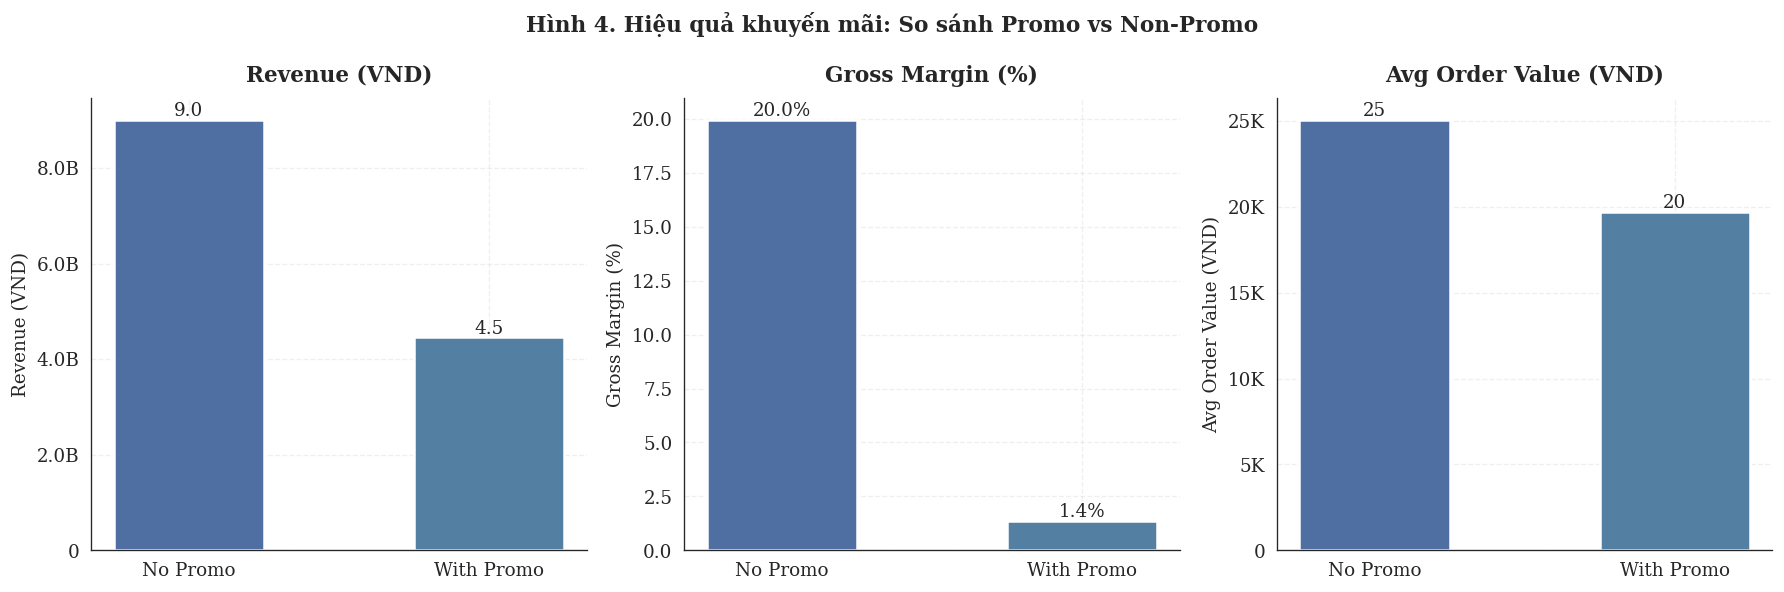


- Gross Margin WITH Promo:    1.4%
- Gross Margin WITHOUT Promo: 20.0%
- Chênh lệch: 18.6 percentage points


In [ ]:
def fmt_money(val):
    if val >= 1e9:
        return f"{val/1e9:.1f}B"
    elif val >= 1e6:
        return f"{val/1e6:.1f}M"
    elif val >= 1e3:
        return f"{val/1e3:.0f}K"
    else:
        return f"{val:.0f}"

promo_comp = oi_valid.groupby("has_promo").agg(
    Revenue=("revenue","sum"),
    GrossProfit=("gross_profit","sum"),
    Units=("quantity","sum"),
    AvgOrderValue=("revenue","mean"),
    Orders=("order_id","nunique")
).reset_index()

promo_comp["GrossMargin"] = promo_comp["GrossProfit"] / promo_comp["Revenue"] * 100
promo_comp["Label"] = promo_comp["has_promo"].map({True:"With Promo", False:"No Promo"})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("Revenue","Revenue (VND)"),
    ("GrossMargin","Gross Margin (%)"),
    ("AvgOrderValue","Avg Order Value (VND)")
]

for i, (metric, ylabel) in enumerate(metrics):

    colors = [C_2 if p else C_1 for p in promo_comp["has_promo"]]

    bars = axes[i].bar(
        promo_comp["Label"],
        promo_comp[metric],
        color=colors,
        edgecolor="white",
        linewidth=1.5,
        width=0.5
    )

    for bar, val in zip(bars, promo_comp[metric]):
        if metric == "Revenue":
            fmt = f"{val/1e9:.1f}"
        elif metric == "GrossMargin":
            fmt = f"{val:.1f}%"
        elif metric == "AvgOrderValue":
            fmt = f"{val/1e3:.0f}"

        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height()*1,
            fmt,
            ha="center",
            va="bottom",
            fontsize=11
        )

    axes[i].set_title(ylabel, fontweight="bold", pad=10)
    axes[i].set_ylabel(ylabel)

    if metric in ["Revenue", "AvgOrderValue"]:
        axes[i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: fmt_money(x))
        )

    sns.despine(ax=axes[i], top=True, right=True)

fig.suptitle(
    "Hình 4. Hiệu quả khuyến mãi: So sánh Promo vs Non-Promo",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

margin_promo   = promo_comp[promo_comp["has_promo"]==True]["GrossMargin"].values[0]
margin_nopromo = promo_comp[promo_comp["has_promo"]==False]["GrossMargin"].values[0]

print(f"\n- Gross Margin WITH Promo:    {margin_promo:.1f}%")
print(f"- Gross Margin WITHOUT Promo: {margin_nopromo:.1f}%")
print(f"- Chênh lệch: {margin_nopromo - margin_promo:.1f} percentage points")

---
## Hình 5. The Discount Trap — Scatter Plot

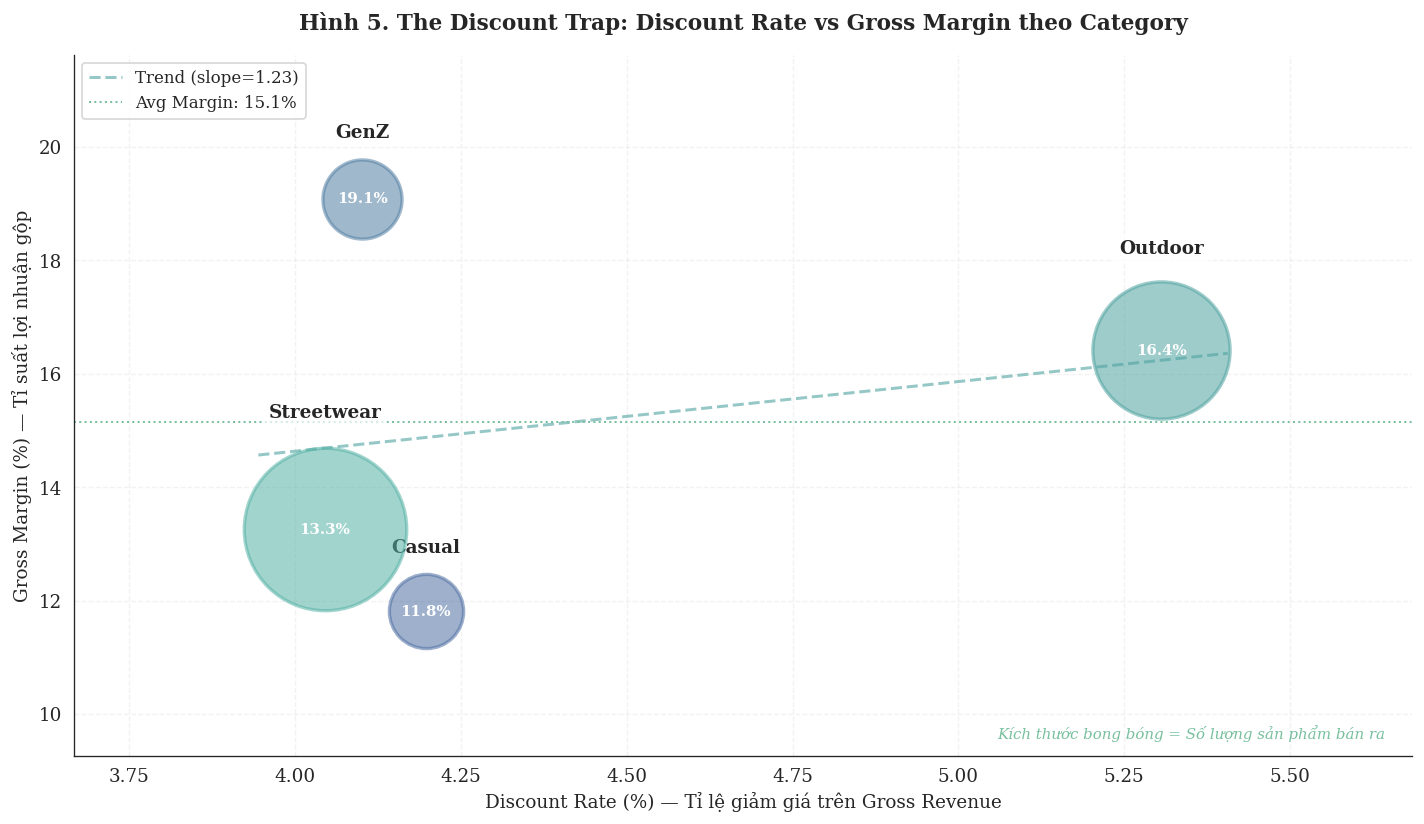


- Discount Rate & Gross Margin theo Category:
  category  DiscountRate  GrossMargin      Revenue
   Outdoor      5.305959    16.415522 2.041050e+09
    Casual      4.197452    11.808612 3.763843e+08
      GenZ      4.101155    19.082542 2.822937e+08
Streetwear      4.044885    13.253256 1.077074e+10


In [ ]:
cat_diag = oi_valid.groupby("category").agg(
    Revenue=("revenue","sum"),
    GrossRevenue=("gross_revenue","sum"),
    Discount=("discount_amount","sum"),
    GrossProfit=("gross_profit","sum"),
    Units=("quantity","sum")).reset_index()
cat_diag["DiscountRate"] = cat_diag["Discount"] / cat_diag["GrossRevenue"] * 100
cat_diag["GrossMargin"]  = cat_diag["GrossProfit"] / cat_diag["Revenue"] * 100

fig, ax = plt.subplots(figsize=(12, 7))
sizes = (cat_diag["Units"] / cat_diag["Units"].max()) * 8000 + 1500

for i, (_, row) in enumerate(cat_diag.iterrows()):
    ax.scatter(row["DiscountRate"], row["GrossMargin"],
               s=sizes[i],
               color=C_PALETTE[i % len(C_PALETTE)],
               alpha=0.55, edgecolors=C_PALETTE[i % len(C_PALETTE)],
               linewidth=2, zorder=3)
    ax.annotate(
        row["category"],
        xy=(row["DiscountRate"], row["GrossMargin"]),
        xytext=(0, np.sqrt(sizes[i]) * 0.6 + 6),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7)
    )

    ax.text(row["DiscountRate"], row["GrossMargin"],
            f'{row["GrossMargin"]:.1f}%',
            ha="center", va="center", fontsize=9,
            color="white", fontweight="bold", zorder=4)

z = np.polyfit(cat_diag["DiscountRate"], cat_diag["GrossMargin"], 1)
p = np.poly1d(z)
xline = np.linspace(cat_diag["DiscountRate"].min() - 0.1,
                    cat_diag["DiscountRate"].max() + 0.1, 100)
ax.plot(xline, p(xline), "--", color=C_3, lw=1.8, alpha=0.6,
        label=f"Trend (slope={z[0]:.2f})", zorder=2)

avg_margin = cat_diag["GrossMargin"].mean()
ax.axhline(y=avg_margin, color=C_5, lw=1.2, linestyle=":",
           label=f"Avg Margin: {avg_margin:.1f}%", zorder=2)

x_pad = (cat_diag["DiscountRate"].max() - cat_diag["DiscountRate"].min()) * 0.3
y_pad = (cat_diag["GrossMargin"].max() - cat_diag["GrossMargin"].min()) * 0.35
ax.set_xlim(cat_diag["DiscountRate"].min() - x_pad,
            cat_diag["DiscountRate"].max() + x_pad)
ax.set_ylim(cat_diag["GrossMargin"].min() - y_pad,
            cat_diag["GrossMargin"].max() + y_pad)

ax.set_xlabel("Discount Rate (%) — Tỉ lệ giảm giá trên Gross Revenue", fontsize=11)
ax.set_ylabel("Gross Margin (%) — Tỉ suất lợi nhuận gộp", fontsize=11)
ax.set_title("Hình 5. The Discount Trap: Discount Rate vs Gross Margin theo Category",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="upper left", frameon=True, fontsize=10)
ax.grid(alpha=0.25, linestyle="--")
ax.text(0.98, 0.02, "Kích thước bong bóng = Số lượng sản phẩm bán ra",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, color=C_5, style="italic")

plt.tight_layout()
plt.show()

print("\n- Discount Rate & Gross Margin theo Category:")
print(cat_diag[["category","DiscountRate","GrossMargin","Revenue"]]
      .sort_values("DiscountRate", ascending=False).to_string(index=False))

---
## Hình 6. Cohort Retention Analysis

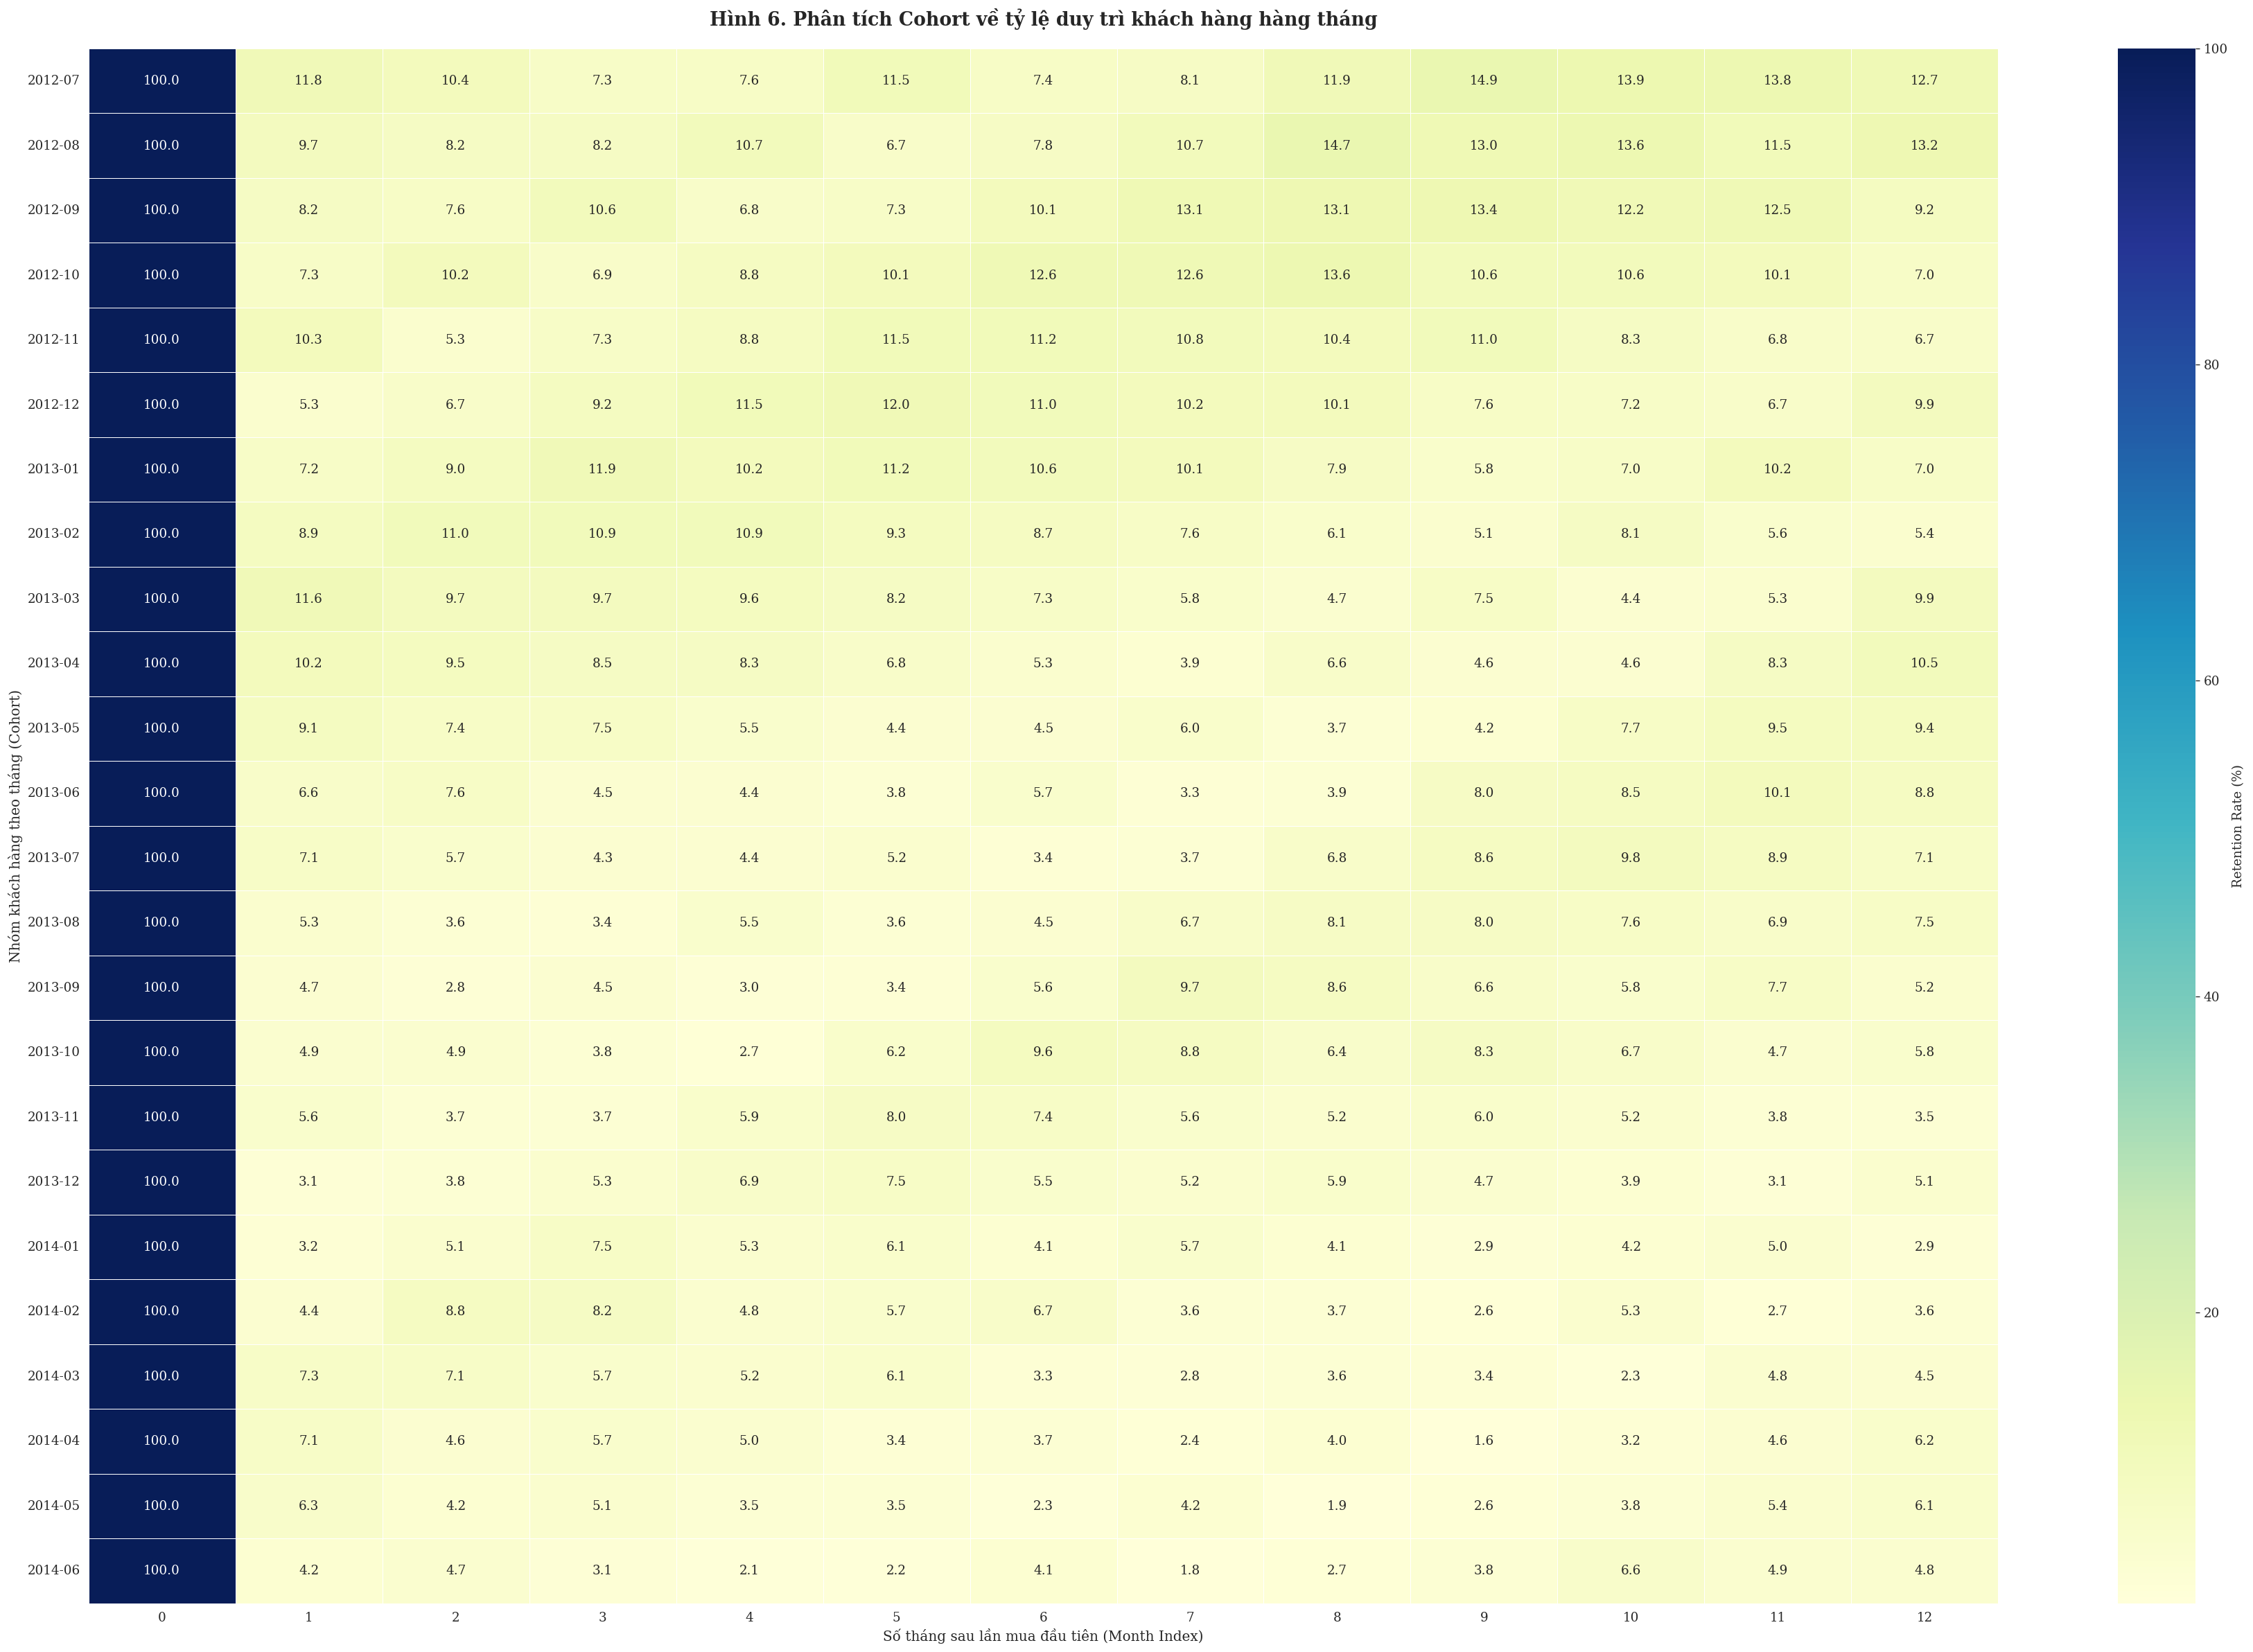

- Tỉ lệ giữ chân trung bình tháng đầu tiên (Month 1): 3.19%
- Tỉ lệ khách hàng rời bỏ ngay sau tháng đầu (Churn): 96.81%


In [ ]:
orders_cust = orders[orders["order_status"].isin(["delivered", "shipped"])].copy()
orders_cust["order_date"] = pd.to_datetime(orders_cust["order_date"])
orders_cust["order_ym"] = orders_cust["order_date"].dt.to_period("M")

first_order = orders_cust.groupby("customer_id")["order_date"].min().dt.to_period("M").reset_index()
first_order.columns = ["customer_id", "cohort_month"]
orders_cust = orders_cust.merge(first_order, on="customer_id", how="left")

def get_month_diff(df):
    return (df["order_ym"].view(dtype='int64') - df["cohort_month"].view(dtype='int64'))

orders_cust["months_since_first"] = get_month_diff(orders_cust)
cohort_data = orders_cust[
    (orders_cust["cohort_month"].dt.year >= 2012) &
    (orders_cust["cohort_month"].dt.year <= 2022) &
    (orders_cust["months_since_first"] <= 12)
].copy()

cohort_pivot = cohort_data.pivot_table(
    index="cohort_month",
    columns="months_since_first",
    values="customer_id",
    aggfunc="nunique"
)

cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(30, 20))
sns.set_style("white", {"font.family": "serif"})
plot_data = retention_matrix.head(24)

ax = sns.heatmap(
    plot_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)

ax.set_yticklabels([tick.get_text() for tick in ax.get_yticklabels()], rotation=0)

plt.title("Hình 6. Phân tích Cohort về tỷ lệ duy trì khách hàng hàng tháng", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Số tháng sau lần mua đầu tiên (Month Index)", fontsize=12)
plt.ylabel("Nhóm khách hàng theo tháng (Cohort)", fontsize=12)
plt.tight_layout()
plt.show()

avg_retention = retention_matrix.mean()
print(f"- Tỉ lệ giữ chân trung bình tháng đầu tiên (Month 1): {avg_retention[1]:.2f}%")
print(f"- Tỉ lệ khách hàng rời bỏ ngay sau tháng đầu (Churn): {100 - avg_retention[1]:.2f}%")

---
## Hình 7. Regional Return Intelligence

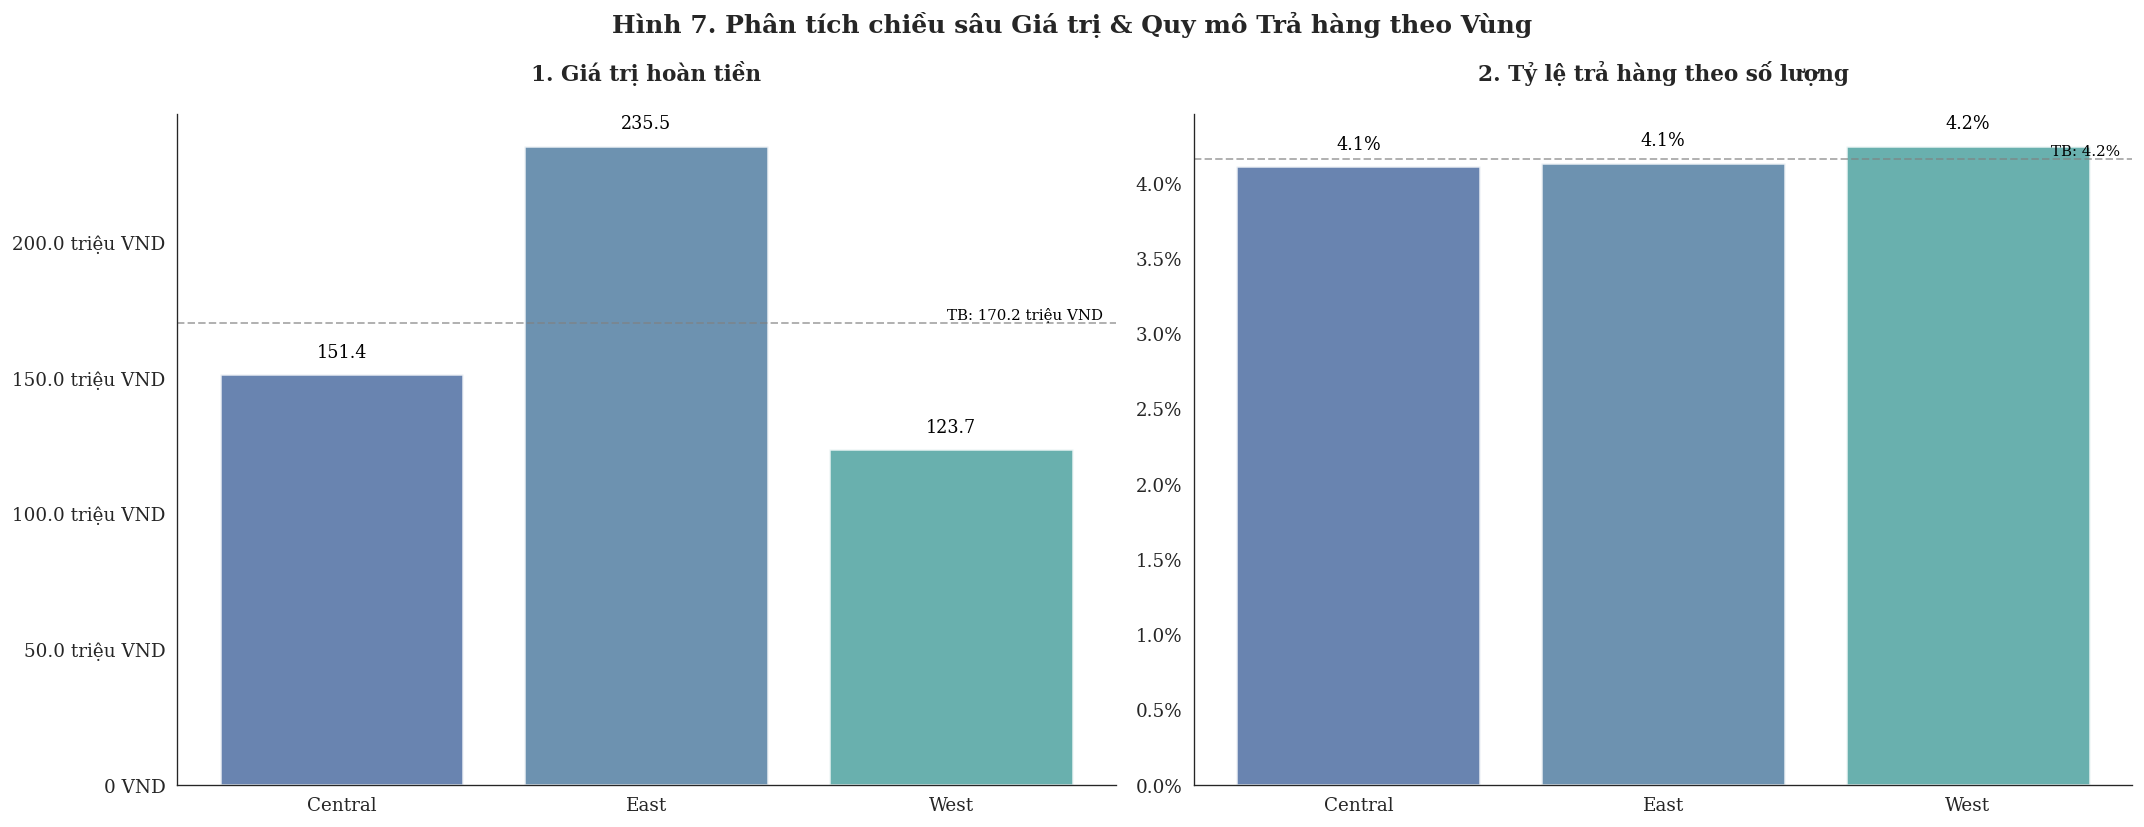

  Tổng doanh thu toàn công ty   : 13.5 tỷ VND
  Tổng đơn hàng bị trả lại      : 36,062 đơn
  Tổng giá trị hoàn tiền        : 510.6 triệu VND
  Tỷ lệ hoàn tiền / doanh thu   : 3.79%
  Tỷ lệ trả hàng TB (số lượng)  : 4.16%
  Rủi ro tài chính cao nhất     : West
  Rủi ro vận hành cao nhất      : West


In [ ]:
region_sales = oi_valid.groupby("region").agg(
    TotalRevenue=("revenue", "sum"),
    TotalSalesQty=("quantity", "sum")
).reset_index()

returns_geo = returns.merge(orders[["order_id", "zip"]], on="order_id", how="left")
returns_geo = returns_geo.merge(geography[["zip", "region"]].drop_duplicates(), on="zip", how="left")

region_returns = returns_geo.groupby("region").agg(
    TotalRefund=("refund_amount", "sum"),
    TotalReturnQty=("return_quantity", "sum")
).reset_index()

df_final = region_sales.merge(region_returns, on="region", how="left").fillna(0)
df_final["ReturnRate_Value"] = (df_final["TotalRefund"] / df_final["TotalRevenue"]) * 100
df_final["ReturnRate_Qty"]   = (df_final["TotalReturnQty"] / df_final["TotalSalesQty"]) * 100
df_final = df_final.sort_values("region")

total_returned_orders = returns["order_id"].nunique()
total_revenue_all     = oi_valid["revenue"].sum()
total_refund_all      = returns["refund_amount"].sum()

avg_val_rate = total_refund_all / total_revenue_all * 100
avg_qty_rate = df_final["TotalReturnQty"].sum() / df_final["TotalSalesQty"].sum() * 100
max_val_reg  = df_final.loc[df_final["ReturnRate_Value"].idxmax(), "region"]
max_qty_reg  = df_final.loc[df_final["ReturnRate_Qty"].idxmax(), "region"]

regions   = df_final["region"].tolist()
color_map = {regions[i]: [C_1, C_2, C_3, C_4][i] for i in range(len(regions))}
colors    = [color_map[r] for r in regions]

def fmt_mil_plain(val):
    s = fmt_mil(val)
    return s.rstrip("MBKmb")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

bars1 = axes[0].bar(df_final["region"], df_final["TotalRefund"],
                    color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars1, df_final["TotalRefund"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + df_final["TotalRefund"].max() * 0.02,
        f"{val/1e6:.1f}",
        ha="center", va="bottom", fontsize=10.5, fontweight="500", color="black"
    )

axes[0].set_title("1. Giá trị hoàn tiền", pad=20, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))

avg_refund = df_final["TotalRefund"].mean()
axes[0].axhline(avg_refund, color="gray", lw=1.2, ls="--", alpha=0.6)
axes[0].text(
    len(regions) - 0.5, avg_refund * 1,
    f"TB: {fmt_mil(avg_refund)}",
    ha="right", va="bottom", fontsize=9, color="black"
)

bars2 = axes[1].bar(df_final["region"], df_final["ReturnRate_Qty"],
                    color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)

for bar, rate in zip(bars2, df_final["ReturnRate_Qty"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        rate + df_final["ReturnRate_Qty"].max() * 0.02,
        f"{rate:.1f}%",
        ha="center", va="bottom", fontsize=10.5, fontweight="500", color="black"
    )

axes[1].set_title("2. Tỷ lệ trả hàng theo số lượng", pad=20, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

axes[1].axhline(avg_qty_rate, color="gray", lw=1.2, ls="--", alpha=0.6)
axes[1].text(
    len(regions) - 0.5, avg_qty_rate * 1,
    f"TB: {avg_qty_rate:.1f}%",
    ha="right", va="bottom", fontsize=9, color="black"
)

for ax in axes:
    sns.despine(ax=ax, top=True, right=True)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=11)

fig.suptitle(
    "Hình 7. Phân tích chiều sâu Giá trị & Quy mô Trả hàng theo Vùng",
    fontsize=15, fontweight="bold"
)

plt.tight_layout()
plt.show()

print(f"  Tổng doanh thu toàn công ty   : {fmt_mil(total_revenue_all)}")
print(f"  Tổng đơn hàng bị trả lại      : {total_returned_orders:,} đơn")
print(f"  Tổng giá trị hoàn tiền        : {fmt_mil(total_refund_all)}")
print(f"  Tỷ lệ hoàn tiền / doanh thu   : {avg_val_rate:.2f}%")
print(f"  Tỷ lệ trả hàng TB (số lượng)  : {avg_qty_rate:.2f}%")
print(f"  Rủi ro tài chính cao nhất     : {max_val_reg}")
print(f"  Rủi ro vận hành cao nhất      : {max_qty_reg}")

---
## Hình 8. Return Rate Heatmap

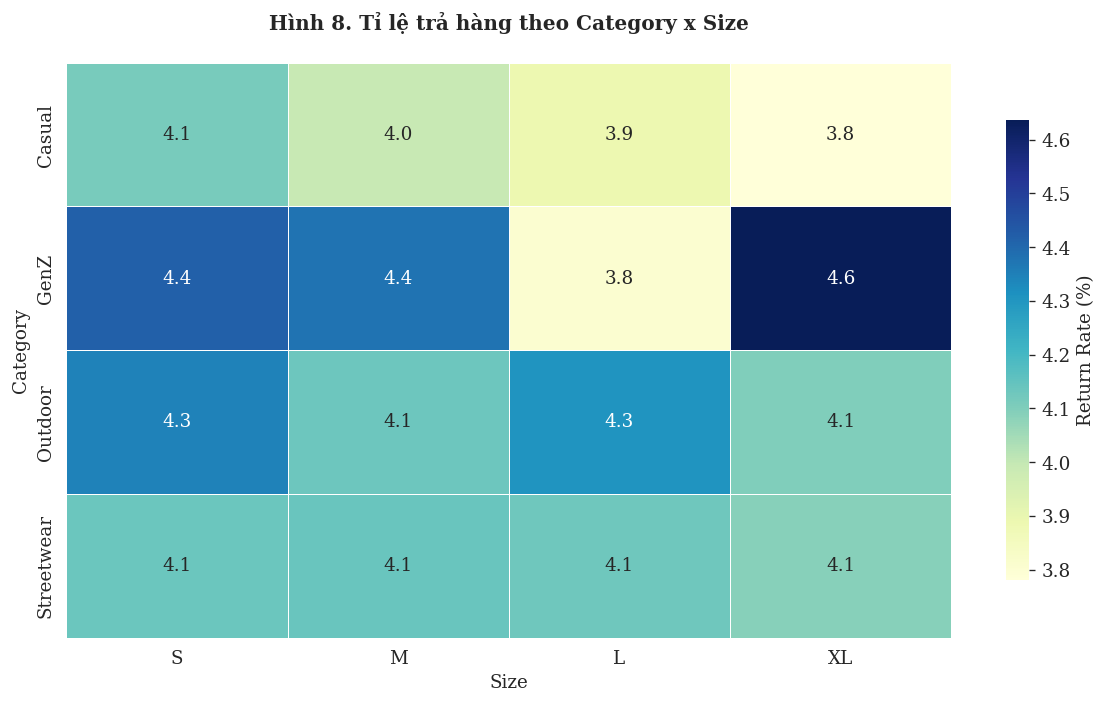


- Top 5 Category-Size có Return Rate cao nhất:
category size  return_rate  return_quantity   sold
    GenZ   XL     4.636168              906  19542
    GenZ    S     4.417790             2081  47105
    GenZ    M     4.377916             1670  38146
 Outdoor    S     4.347147             8907 204893
 Outdoor    L     4.307602            11426 265252


In [ ]:
ret_merged = returns.merge(
    order_items[["order_id","product_id","quantity"]], on=["order_id","product_id"], how="left")
ret_merged = ret_merged.merge(
    products[["product_id","category","size"]], on="product_id", how="left")

sold_by_cat_size = oi_valid.groupby(["category","size"])["quantity"].sum().reset_index()
sold_by_cat_size.columns = ["category","size","sold"]

ret_by_cat_size = ret_merged.groupby(["category","size"])["return_quantity"].sum().reset_index()
ret_rate = ret_by_cat_size.merge(sold_by_cat_size, on=["category","size"], how="left")
ret_rate["return_rate"] = ret_rate["return_quantity"] / ret_rate["sold"] * 100

pivot_ret = ret_rate.pivot(index="category", columns="size", values="return_rate")
size_order = [s for s in ["S","M","L","XL"] if s in pivot_ret.columns]
pivot_ret = pivot_ret[size_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_ret, ax=ax,
            cmap="YlGnBu",
            annot=True, fmt=".1f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Return Rate (%)", "shrink": 0.8})

ax.set_title("Hình 8. Tỉ lệ trả hàng theo Category x Size\n",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Size")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

print("\n- Top 5 Category-Size có Return Rate cao nhất:")
print(ret_rate.sort_values("return_rate", ascending=False).head(5)
      [["category","size","return_rate","return_quantity","sold"]].to_string(index=False))

---
## Hình 9. P&L Waterfall

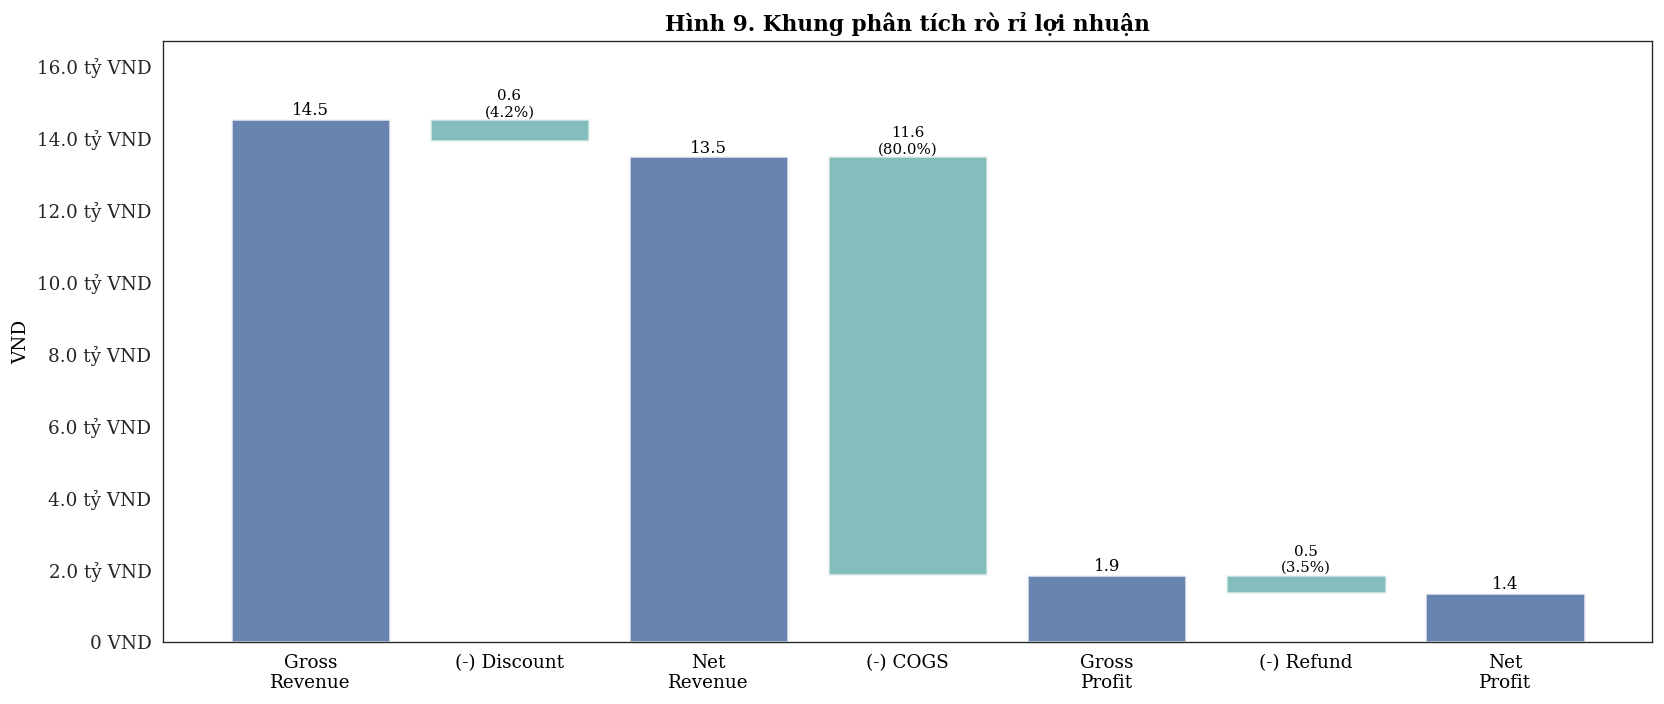

In [ ]:
gross_rev    = oi_valid["gross_revenue"].sum()
discount_tot = oi_valid["discount_amount"].sum()
net_rev      = oi_valid["revenue"].sum()
cogs_tot     = oi_valid["cogs_total"].sum()
gross_profit = oi_valid["gross_profit"].sum()
refund_tot   = returns["refund_amount"].sum()
net_profit   = gross_profit - refund_tot

labels = ["Gross\nRevenue","(-) Discount","Net\nRevenue",
          "(-) COGS","Gross\nProfit","(-) Refund","Net\nProfit"]
values = [gross_rev, -discount_tot, net_rev, -cogs_tot, gross_profit, -refund_tot, net_profit]
running = [0, gross_rev, gross_rev-discount_tot, net_rev,
           net_rev-cogs_tot, gross_profit, gross_profit-refund_tot]

bar_colors = [C_1, C_3, C_1, C_3, C_1, C_3, C_1]
is_total   = [True, False, True, False, True, False, True]

fig, ax = plt.subplots(figsize=(14, 6))

for i, (label, val, start, color, total) in enumerate(
        zip(labels, values, running, bar_colors, is_total)):

    if total:
        ax.bar(i, abs(val), bottom=0, color=color, alpha=0.85,
               edgecolor="white", linewidth=1.5)
        ax.text(i, abs(val),
                f"{abs(val)/1e9:.1f}",
                ha="center", va="bottom", fontsize=10, color="black")
    else:
        bottom = start + val if val < 0 else start
        ax.bar(i, abs(val), bottom=bottom, color=color, alpha=0.7,
               edgecolor="white", linewidth=1.5)
        pct = abs(val) / gross_rev * 100
        top_of_bar = max(start, start + val)
        ax.text(i, top_of_bar,
                f"{abs(val)/1e9:.1f}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=9, color="black")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11, color="black")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
ax.set_ylabel("VND", color="black")
ax.set_title("Hình 9. Khung phân tích rò rỉ lợi nhuận",
             fontsize=13, fontweight="bold", color="black")

ax.set_ylim(0, gross_rev * 1.15)
plt.tight_layout()
plt.show()

---
## Hình 10. RFM Segmentation

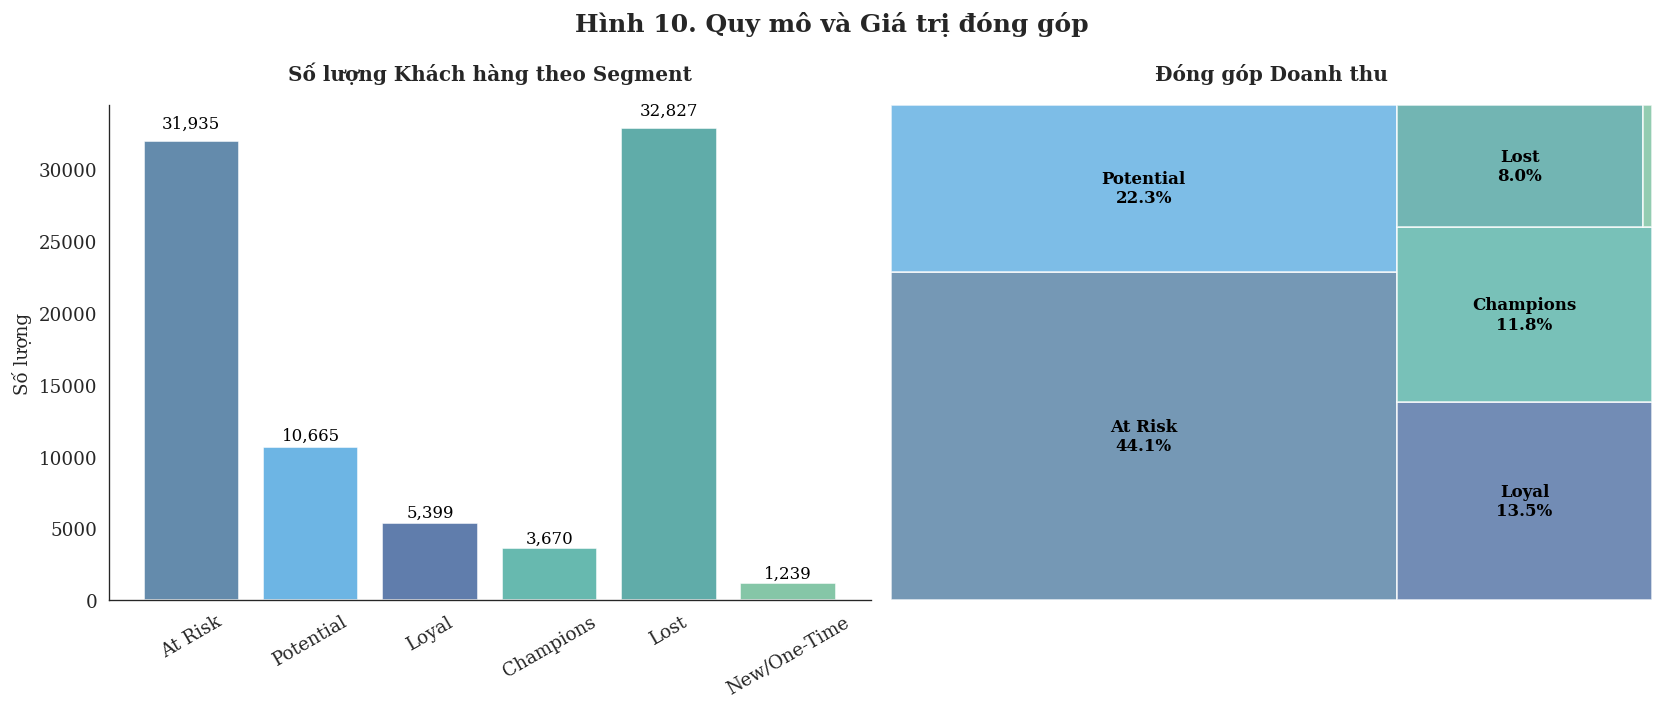

In [ ]:
snapshot_date = orders_cust["order_date"].max() + pd.Timedelta(days=1)
rfm = orders_cust.groupby("customer_id").agg(
    Recency=("order_date",  lambda x: (snapshot_date - x.max()).days),
    Frequency=("order_id", "nunique")).reset_index()

cust_rev = oi_valid.groupby("customer_id")["revenue"].sum().reset_index()
rfm = rfm.merge(cust_rev, on="customer_id", how="left")
rfm.rename(columns={"revenue":"Monetary"}, inplace=True)
rfm["Monetary"] = rfm["Monetary"].fillna(0)

def rfm_segment(row):
    if row["Recency"] <= 90  and row["Frequency"] >= 5: return "Champions"
    if row["Recency"] <= 180 and row["Frequency"] >= 3: return "Loyal"
    if row["Recency"] <= 365 and row["Frequency"] >= 2: return "Potential"
    if row["Recency"] > 365  and row["Frequency"] >= 3: return "At Risk"
    if row["Recency"] > 365  and row["Frequency"] >= 1: return "Lost"
    return "New/One-Time"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

rfm_summary = rfm.groupby("Segment").agg(
    Customers=("customer_id","count"),
    TotalRevenue=("Monetary","sum")).reset_index()
rfm_summary["RevenueShare"] = rfm_summary["TotalRevenue"] / rfm_summary["TotalRevenue"].sum() * 100
rfm_summary = rfm_summary.sort_values("TotalRevenue", ascending=False)

seg_colors = {"Champions":C_4, "Loyal":C_1, "Potential":"#5DADE2",
              "At Risk":C_2, "Lost":C_3, "New/One-Time":C_5}
colors_rfm = [seg_colors.get(s, C_5) for s in rfm_summary["Segment"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].bar(rfm_summary["Segment"], rfm_summary["Customers"],
            color=colors_rfm, edgecolor="white", alpha=0.9)

for bar, val in zip(axes[0].patches, rfm_summary["Customers"]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f"{val:,}", ha="center", va="bottom", fontsize=10, color="black")

axes[0].set_title("Số lượng Khách hàng theo Segment", fontsize=12, fontweight="bold", pad=15)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Số lượng")

sns.despine(ax=axes[0], top=True, right=True, left=False, bottom=False)

labels_filtered = [
    f"{row['Segment']}\n{row['RevenueShare']:.1f}%" if row['RevenueShare'] >= 5 else ""
    for _, row in rfm_summary.iterrows()
]

squarify.plot(sizes=rfm_summary['TotalRevenue'], label=labels_filtered,
              color=colors_rfm, alpha=0.8, ax=axes[1],
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'black'})

axes[1].set_title("Đóng góp Doanh thu", fontsize=12, fontweight="bold", pad=15)
axes[1].axis('off')

fig.suptitle("Hình 10. Quy mô và Giá trị đóng góp",
             fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

---
## Hình 11. Inventory Stockout Analysis

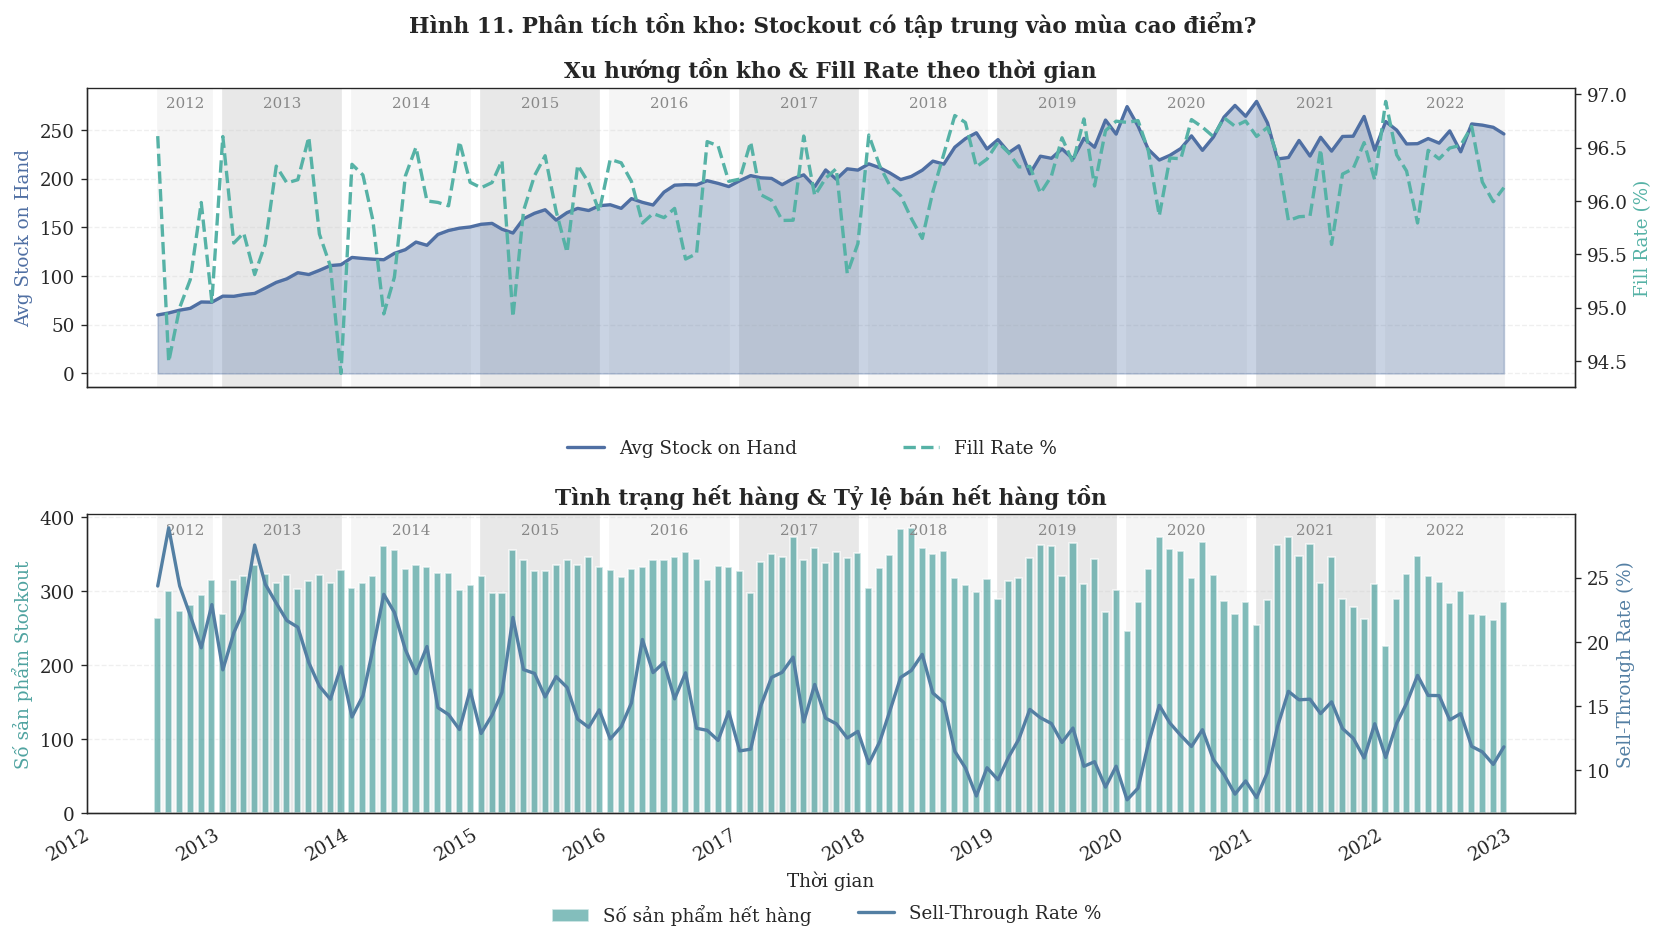

In [ ]:
inv_monthly = inventory.groupby(["year","month"]).agg(
    AvgStock=("stock_on_hand","mean"),
    StockoutFlag=("stockout_flag","sum"),
    SellThrough=("sell_through_rate","mean"),
    FillRate=("fill_rate","mean")
).reset_index()

inv_monthly["date"] = pd.to_datetime(
    inv_monthly["year"].astype(str) + "-" +
    inv_monthly["month"].astype(str) + "-01"
)

inv_monthly = inv_monthly.sort_values("date")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

years_sorted = sorted(inv_monthly["year"].unique())
band_colors  = ["#f5f5f5", "#e8e8e8"]

for i, yr in enumerate(years_sorted):
    mask    = inv_monthly["year"] == yr
    x_start = inv_monthly.loc[mask, "date"].min()
    x_end   = inv_monthly.loc[mask, "date"].max()
    for ax in axes:
        ax.axvspan(x_start, x_end,
                   color=band_colors[i % 2],
                   alpha=1.0, zorder=0)

axes[0].fill_between(
    inv_monthly["date"],
    inv_monthly["AvgStock"],
    alpha=0.3,
    color=C_1,
    zorder=2
)

axes[0].plot(
    inv_monthly["date"],
    inv_monthly["AvgStock"],
    color=C_1,
    lw=2,
    label="Avg Stock on Hand",
    zorder=2
)

ax0r = axes[0].twinx()
ax0r.plot(
    inv_monthly["date"],
    inv_monthly["FillRate"] * 100,
    "--",
    color=C_4,
    lw=2,
    label="Fill Rate %",
    zorder=2
)

axes[0].set_ylabel("Avg Stock on Hand", color=C_1)
ax0r.set_ylabel("Fill Rate (%)", color=C_4)
ax0r.spines["top"].set_visible(False)

axes[0].legend(loc="upper center", bbox_to_anchor=(0.4, -0.12), frameon=False)
ax0r.legend(loc="upper center", bbox_to_anchor=(0.6, -0.12), frameon=False)

axes[0].set_title("Xu hướng tồn kho & Fill Rate theo thời gian")
axes[0].grid(axis='y', linestyle='--', alpha=0.3, zorder=1)

axes[0].figure.canvas.draw()
y_bottom, y_top = axes[0].get_ylim()
y_offset = (y_top - y_bottom) * 0.03

for i, yr in enumerate(years_sorted):
    mask    = inv_monthly["year"] == yr
    x_start = inv_monthly.loc[mask, "date"].min()
    x_end   = inv_monthly.loc[mask, "date"].max()
    x_mid   = x_start + (x_end - x_start) / 2
    axes[0].text(
        x_mid, y_top - y_offset,
        str(yr),
        ha="center", va="top",
        fontsize=9, color="#888888",
        zorder=3
    )

axes[1].bar(
    inv_monthly["date"],
    inv_monthly["StockoutFlag"],
    width=20,
    color=C_3,
    alpha=0.7,
    label="Số sản phẩm hết hàng",
    zorder=2
)

ax1r = axes[1].twinx()
ax1r.plot(
    inv_monthly["date"],
    inv_monthly["SellThrough"] * 100,
    color=C_2,
    lw=2,
    label="Sell-Through Rate %",
    zorder=2
)

axes[1].set_ylabel("Số sản phẩm Stockout", color=C_3)
ax1r.set_ylabel("Sell-Through Rate (%)", color=C_2)
ax1r.spines["top"].set_visible(False)

axes[1].set_title("Tình trạng hết hàng & Tỷ lệ bán hết hàng tồn")
axes[1].set_xlabel("Thời gian")

axes[1].legend(loc="upper center", bbox_to_anchor=(0.4, -0.25), frameon=False)
ax1r.legend(loc="upper center", bbox_to_anchor=(0.6, -0.25), frameon=False)

axes[1].grid(axis='y', linestyle='--', alpha=0.3, zorder=1)

y_bottom2, y_top2 = axes[1].get_ylim()
y_offset2 = (y_top2 - y_bottom2) * 0.03

for i, yr in enumerate(years_sorted):
    mask    = inv_monthly["year"] == yr
    x_start = inv_monthly.loc[mask, "date"].min()
    x_end   = inv_monthly.loc[mask, "date"].max()
    x_mid   = x_start + (x_end - x_start) / 2
    axes[1].text(
        x_mid, y_top2 - y_offset2,
        str(yr),
        ha="center", va="top",
        fontsize=9, color="#888888",
        zorder=3
    )

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0].tick_params(axis='x', labelbottom=True)
fig.autofmt_xdate()

fig.suptitle(
    "Hình 11. Phân tích tồn kho: Stockout có tập trung vào mùa cao điểm?",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()